Install PyNNCML From pip
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
pynncml version: 0.3.7
✓ OpenMRG_Sweden folder found at: C:\Users\after\FieldSense\dataset\open_datasets\OpenMRG_Sweden
✓ Data file (cml.nc) found in local dataset folder
  Note: PyNNCML uses its default location: C:\Users\after\FieldSense\projects\SY_Data_Driven\data\OpenMRG.zip
  The local dataset at C:\Users\after\FieldSense\dataset\open_datasets\OpenMRG_Sweden will not be used automatically
File already exists at desired location ./data/OpenMRG.zip
Not downloading!



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
100%|████████████████████████████████████████████████████████████████████████████████| 728/728 [01:55<00:00,  6.29it/s]


(data_path='./data/', change2min_max=False, xy_min=None, xy_max=None, time_slice=None, link2gauge_distance=2000, window_size_in_min=15, multiple_gauges_per_link=False, link_selection: pynncml.datasets.xarray_processing.LinkSelection = <LinkSelection.GAUGEONLY: 1>)


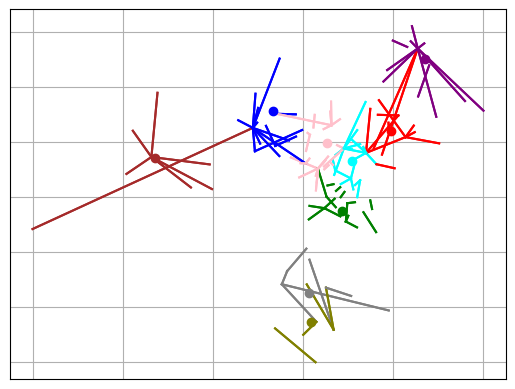

In [2]:
import sys
import os

if os.path.exists('C:/Users/after/FieldSense/core/scientific_packages/pynncml'):
    print("Import PyNNCML From Code")
    import sys, os
    FIELDSENSE_ROOT = r"C:\Users\after\FieldSense"  
    if FIELDSENSE_ROOT not in sys.path:
        sys.path.insert(0, FIELDSENSE_ROOT)
else:
    print("Install PyNNCML From pip")
    %pip install pynncml

import numpy as np
import matplotlib as mpl
import inspect
import pynncml as pnc  # type: ignore
print("pynncml version:", getattr(pnc, "__version__", "unknown"))
import torch
import math
from matplotlib import pyplot as plt
from pynncml import plot_wet_dry_detection_mark
from tqdm import tqdm
import scipy
from sklearn import metrics

#  @title Hyper-parameters
batch_size = 16  # @param{type:"integer"}
window_size = 32  # @param{type:"integer"}
rnn_n_features = 128  # @param{type:"integer"}
metadata_n_features = 32  # @param{type:"integer"}
n_layers = 2  # @param{type:"integer"}
lr = 1e-4  # @param{type:"number"}
weight_decay = 1e-4  # @param{type:"number"}
rnn_type = pnc.neural_networks.RNNType.GRU  # RNN Type
n_epochs = 200  # @param{type:"integer"}
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


time_slice = slice("2015-06-01", "2015-07-10")  # Time Interval

# Check if local OpenMRG dataset exists in FieldSense dataset folder
openmrg_folder = os.path.join("..", "..", "dataset", "open_datasets", "OpenMRG_Sweden")
openmrg_cml_nc = os.path.join(openmrg_folder, "cml", "cml_metadata.csv")

# PyNNCML's default location (where it downloads/looks for data)
pynncml_default_location = os.path.abspath(os.path.join(".", "data", "OpenMRG.zip"))

if os.path.exists(openmrg_folder):
    print(f"✓ OpenMRG_Sweden folder found at: {os.path.abspath(openmrg_folder)}")
    if os.path.exists(openmrg_cml_nc):
        print(f"✓ Data file (cml.nc) found in local dataset folder")
        print(f"  Note: PyNNCML uses its default location: {pynncml_default_location}")
        print(f"  The local dataset at {os.path.abspath(openmrg_folder)} will not be used automatically")
    else:
        print(f"⚠ Data file (cml.nc) NOT found in: {os.path.abspath(openmrg_cml_nc)}")
        print(f"  PyNNCML will use/download data from: {pynncml_default_location}")
else:
    print(f"⚠ OpenMRG_Sweden folder not found at: {os.path.abspath(openmrg_folder)}")
    print(f"  PyNNCML will use/download data from: {pynncml_default_location}")

dataset = pnc.datasets.loader_open_mrg_dataset(time_slice=time_slice)
print(inspect.signature(pnc.datasets.loader_open_mrg_dataset))

#plot links and gages

dataset.link_set.plot_links(scale=True, scale_factor=1.0)
plt.grid()
plt.tick_params(left=False, right=False, labelleft=False, labelbottom=False, bottom=False)
plt.show()

Rain Rate Statistics
Mean[mm/hr]: 0.10113861569949811
Std[mm/hr]: 0.6187717133949918
Parentage of wet samples 8.323200741126744
Parentage of dry samples 91.67679925887326
Exponential Distribution Parameters: (0.0, 0.10113861569949811)


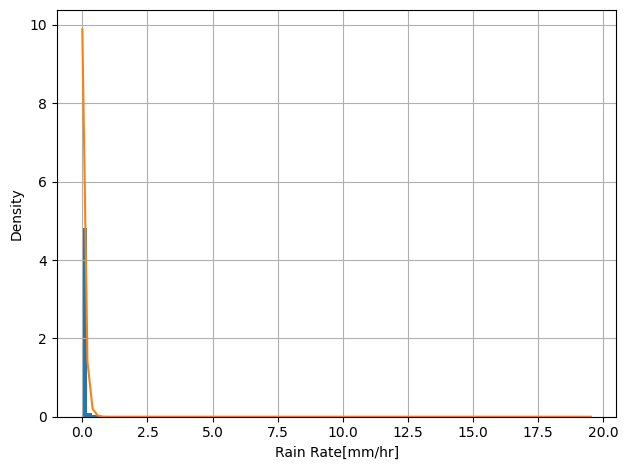

In [3]:
# compute Rain Statistics
rg = np.stack([p.data_array for p in dataset.point_set]).flatten()
param = scipy.stats.expon.fit(rg)
exp_gamma = param[1]
print("Rain Rate Statistics")
print("Mean[mm/hr]:", np.mean(rg))
print("Std[mm/hr]:", np.std(rg))
print("Parentage of wet samples", 100 * np.sum(rg > 0) / rg.size)
print("Parentage of dry samples", 100 * np.sum(rg == 0) / rg.size)
print("Exponential Distribution Parameters:", param)
_ = plt.hist(rg, bins=100, density=True)
plt.plot(np.linspace(0, np.max(rg), 100), scipy.stats.expon.pdf(np.linspace(0, np.max(rg), 100), *param))
plt.grid()
plt.xlabel("Rain Rate[mm/hr]")
plt.ylabel("Density")
plt.tight_layout()
plt.show()


In [16]:
rnn_n_features = 256  # @param{type:"integer"}

training_dataset, validation_dataset = torch.utils.data.random_split(dataset, [0.8, 0.2])
data_loader = torch.utils.data.DataLoader(training_dataset, batch_size)
val_loader = torch.utils.data.DataLoader(validation_dataset, batch_size)
model = pnc.scm.rain_estimation.two_step_network(n_layers=n_layers,  # Number of RNN layers
                                                 rnn_type=rnn_type,  # Type of RNN (GRU, LSTM)
                                                 normalization_cfg=pnc.training_helpers.compute_data_normalization(
                                                     data_loader),
                                                 # Compute the normalization statistics from the training dataset.
                                                 rnn_input_size=180,  # 90 + 90 (RSL + TSL)
                                                 rnn_n_features=rnn_n_features,  # Number of features in the RNN
                                                 metadata_input_size=2,  # Number of metadata features
                                                 metadata_n_features=metadata_n_features,
                                                 # Number of features in the metadata
                                                 pretrained=False).to(
    device)  # Pretrained model is set to False to train the model from scratch.

class RegressionLoss(torch.nn.Module):
    def __init__(self, in_gamma, gamma_s=0.9):
        super(RegressionLoss, self).__init__()
        self.in_gamma = in_gamma
        self.gamma_s = gamma_s

    def forward(self, input, target):
        delta = (target - input) ** 2
        w = 1 - self.gamma_s * torch.exp(-self.in_gamma * target)
        return torch.sum(torch.mean(w * delta, dim=0))


loss_function_rain_est = RegressionLoss(exp_gamma)
loss_function_wet_dry = torch.nn.BCELoss()

# Find lambda values such that at initialization both loss will be equal:
loss_est = 0
loss_detection = 0
with torch.no_grad():
    for rain_rate, rsl, tsl, metadata in data_loader:
        state = model.init_state(batch_size=rsl.shape[0])
        m_step = math.floor(rain_rate.shape[1] / window_size)
        for step in range(m_step):
            _rr = rain_rate[:, step * window_size:(step + 1) * window_size,0].float().to(device)
            _rsl = rsl[:, step * window_size:(step + 1) * window_size, :].to(device)
            _tsl = tsl[:, step * window_size:(step + 1) * window_size, :].to(device)
            rain_estimation_detection, state = model(torch.cat([_rsl, _tsl], dim=-1), metadata.to(device),
                                                     state.detach())
            rain_hat = rain_estimation_detection[:, :, 0]
            rain_detection = rain_estimation_detection[:, :, 1]
            loss_est += loss_function_rain_est(rain_hat, _rr)
            loss_detection += loss_function_wet_dry(rain_detection, (_rr > 0.1).float())
lambda_value = loss_detection / loss_est

In [17]:
# Check if trained model exists and load it
model_path = os.path.abspath("forecast_ws32_lr0.0001_rnn256.pth")

# ALWAYS declare am so later cells can use it
am = pnc.metrics.AverageMetric()

if os.path.exists(model_path):
    print(f"Loading trained model from {model_path}")
    ckpt = torch.load(model_path, map_location=device, weights_only=False)

    # Backward-compatible: allow older files that saved only state_dict
    if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
        model.load_state_dict(ckpt["model_state_dict"])

        # Recreate ra so the plotting cell works after loading
        ra = pnc.metrics.ResultsAccumulator()
        loss_hist = ckpt.get("loss_history", {})
        for l, le, ld in zip(
            loss_hist.get("loss", []),
            loss_hist.get("loss_est", []),
            loss_hist.get("loss_detection", []),
        ):
            ra.add_results(loss=l, loss_est=le, loss_detection=ld)

        # Optional: restore last-epoch snapshot into am (for inspection only)
        am_snapshot = ckpt.get("am_snapshot", None)
        if am_snapshot is not None:
            last = am_snapshot.get("last_epoch", {})
            am.clear()
            if last:
                am.add_results(
                    loss=last.get("loss", 0.0),
                    loss_est=last.get("loss_est", 0.0),
                    loss_detection=last.get("loss_detection", 0.0),
                )

    else:
        # Older weights-only file
        model.load_state_dict(ckpt)
        ra = pnc.metrics.ResultsAccumulator()
        am.clear()

    print(f"Loaded trained model from {model_path}")
    model.eval()  # Set to evaluation mode
    print("Model loaded. Skipping training.")

else:
    print(f"Model file not found at {model_path}. Starting training...")

    opt = torch.optim.RAdam(model.parameters(), lr=lr, weight_decay=weight_decay)
    ra = pnc.metrics.ResultsAccumulator()
    am = pnc.metrics.AverageMetric() 

    model.train()
    print("Start Training")

    for epoch in tqdm(range(n_epochs)):
        am.clear()

        for rain_rate, rsl, tsl, metadata in data_loader:
            state = model.init_state(batch_size=rsl.shape[0])
            m_step = math.floor(rain_rate.shape[1] / window_size)

            for step in range(m_step):
                opt.zero_grad()

                _rr = rain_rate[
                    :, step * window_size : (step + 1) * window_size, 0
                ].float().to(device)
                _rsl = rsl[
                    :, step * window_size : (step + 1) * window_size, :
                ].to(device)
                _tsl = tsl[
                    :, step * window_size : (step + 1) * window_size, :
                ].to(device)

                rain_estimation_detection, state = model(
                    torch.cat([_rsl, _tsl], dim=-1),
                    metadata.to(device),
                    state.detach(),
                )

                rain_hat = rain_estimation_detection[:, :, 0]
                rain_detection = rain_estimation_detection[:, :, 1]

                loss_est = loss_function_rain_est(rain_hat, _rr)
                loss_detection = loss_function_wet_dry(
                    rain_detection, (_rr > 0.1).float()
                )
                loss = lambda_value * loss_est + loss_detection

                loss.backward()
                opt.step()

                am.add_results(
                    loss=loss.item(),
                    loss_est=loss_est.item(),
                    loss_detection=loss_detection.item(),
                )

        ra.add_results(
            loss=am.get_results("loss"),
            loss_est=am.get_results("loss_est"),
            loss_detection=am.get_results("loss_detection"),
        )

    # ---- Save checkpoint ----
    loss_history = {
        "loss": list(ra.get_results("loss")),
        "loss_est": list(ra.get_results("loss_est")),
        "loss_detection": list(ra.get_results("loss_detection")),
    }

    am_snapshot = {
        "last_epoch": {
            "loss": am.get_results("loss"),
            "loss_est": am.get_results("loss_est"),
            "loss_detection": am.get_results("loss_detection"),
        }
    }

    ckpt = {
        "model_state_dict": model.state_dict(),
        "loss_history": loss_history,
        "am_snapshot": am_snapshot,
        "hyperparams": {
            "lr": lr,
            "weight_decay": weight_decay,
            "lambda_value": lambda_value,
            "window_size": window_size,
            "n_epochs": n_epochs,
        },
    }

    torch.save(ckpt, model_path)
    print("Model saved successfully!")



Loading trained model from C:\Users\after\FieldSense\projects\SY_Data_Driven\forecast_ws32_lr0.0001_rnn256.pth
Loaded trained model from C:\Users\after\FieldSense\projects\SY_Data_Driven\forecast_ws32_lr0.0001_rnn256.pth
Model loaded. Skipping training.


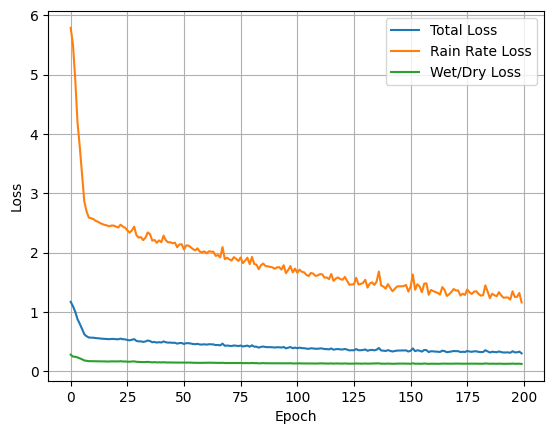

In [18]:
plt.plot(ra.get_results("loss"), label="Total Loss")
plt.plot(ra.get_results("loss_est"), label="Rain Rate Loss")
plt.plot(ra.get_results("loss_detection"), label="Wet/Dry Loss")
plt.grid()
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

Results Detection:
Validation Results of Two-Step RNN
Accuracy[%]: 93.86459129106188
F1 Score: 0.3124665596575709


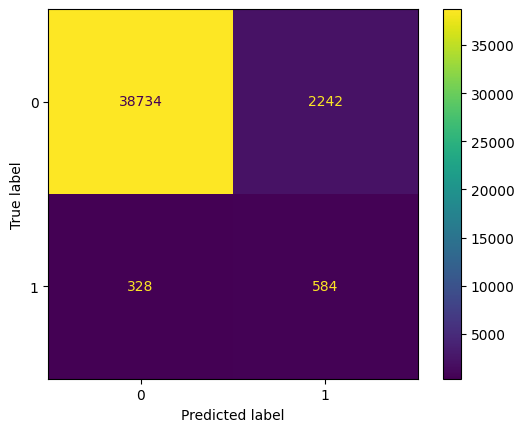

Results Estimation:
-------------------------------------------------- Results Summery --------------------------------------------------
+--------------+--------------------------+----------------------------------------+----------------------------------------+-----------------------------------------+-----------------------------------------+
|    Metric    | 0.0<r<3.9000000953674316 | 3.9000000953674316<r<7.809999942779541 | 7.809999942779541<r<11.710000038146973 | 11.710000038146973<r<15.619999885559082 | 15.619999885559082<r<19.520000457763672 |
+--------------+--------------------------+----------------------------------------+----------------------------------------+-----------------------------------------+-----------------------------------------+
|     RMSE     |           0.38           |                  4.95                  |                  8.16                  |                  12.57                  |                  15.43                  |
|     BIAS     |      

In [19]:
model.eval()
ga = pnc.metrics.GroupAnalysis()
with torch.no_grad():
    for rain_rate, rsl, tsl, metadata in val_loader:
        state = model.init_state(batch_size=rsl.shape[0])
        m_step = math.floor(rain_rate.shape[1] / window_size)
        am.clear()
        rain_ref_list = []
        rain_hat_list = []
        detection_list = []

        for step in range(m_step):
            _rr = rain_rate[:, step * window_size:(step + 1) * window_size,0].float().to(device)
            _rsl = rsl[:, step * window_size:(step + 1) * window_size, :].to(device)
            _tsl = tsl[:, step * window_size:(step + 1) * window_size, :].to(device)
            rain_estimation_detection, state = model(torch.cat([_rsl, _tsl], dim=-1), metadata.to(device),
                                                     state.detach())
            rain_detection = rain_estimation_detection[:, :, 1]
            rain_hat = rain_estimation_detection[:, :, 0] * torch.round(
                rain_detection)  # Rain Rate is computed only for wet samples
            rain_hat_list.append(rain_hat.detach().cpu().numpy())
            rain_ref_list.append(_rr.detach().cpu().numpy())
            ga.append(rain_ref_list[-1], rain_hat_list[-1])
            detection_list.append(torch.round(rain_detection).detach().cpu().numpy())
            delta = rain_hat.squeeze(dim=-1) - _rr
            bias = torch.mean(delta)
            mse = torch.mean(delta ** 2)
            am.add_results(bias=bias.item(), mse=mse.item())
actual = np.concatenate(detection_list).flatten()
predicted = (np.concatenate(rain_ref_list) > 0.1).astype("float").flatten()
confusion_matrix = metrics.confusion_matrix(actual, predicted)
max_rain = np.max(np.concatenate(rain_ref_list))
g_array = np.linspace(0, max_rain, 6)

print("Results Detection:")
print("Validation Results of Two-Step RNN")
print("Accuracy[%]:", 100 * (np.sum(actual == predicted) / actual.size))
print("F1 Score:", metrics.f1_score(actual, predicted))

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=[0, 1])

cm_display.plot()
plt.show()

print("Results Estimation:")
_ = ga.run_analysis(np.stack([g_array[:-1], g_array[1:]], axis=-1))


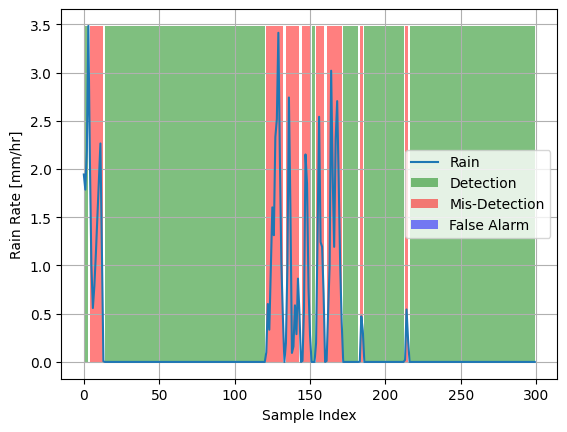

In [20]:
detection_array = np.concatenate(detection_list, axis=1)
rain_ref_array = np.concatenate(rain_ref_list, axis=1)
detection_array = np.round(detection_array)

rain_array = rain_ref_array[0, :300]
detection_array = detection_array[0, :300]
fig, ax = plt.subplots()
x = np.arange(rain_array.shape[0])
ax.plot(x, rain_array, label="Rain")
rain_max = np.max(rain_array)
ax.fill_between(x, rain_max, where=np.logical_or(np.logical_and(detection_array == 1, rain_array > 0),
                                                 np.logical_and(detection_array == 0, rain_array == 0)),
                facecolor='green', alpha=.5, label="Detection")
ax.fill_between(x, rain_max, where=np.logical_and(detection_array == 0, rain_array > 0), facecolor='red',
                alpha=.5, label="Mis-Detection")
ax.fill_between(x, rain_max, where=np.logical_and(detection_array == 1, rain_array == 0), facecolor='blue',
                alpha=.5, label="False Alarm")
plt.legend()
plt.ylabel("Rain Rate [mm/hr]")
plt.xlabel("Sample Index")
plt.grid()
plt.show()

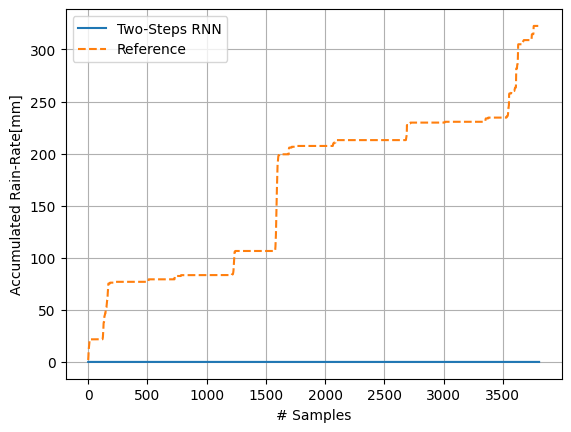

In [21]:
rain_hat_array = np.concatenate(rain_hat_list, axis=1)
rain_ref_array = np.concatenate(rain_ref_list, axis=1)

plt.plot(np.cumsum(np.maximum(rain_hat_array[0, :], 0)), label="Two-Steps RNN")
plt.plot(np.cumsum(rain_ref_array[0, :]), "--", label="Reference")
plt.grid()
plt.legend()
plt.ylabel("Accumulated Rain-Rate[mm]")
plt.xlabel("# Samples")
plt.show()

In [ ]:
#Model Driven

File already exists at desired location ./data/OpenMRG.zip
Not downloading!


100%|████████████████████████████████████████████████████████████████████████████████| 728/728 [32:43<00:00,  2.70s/it]


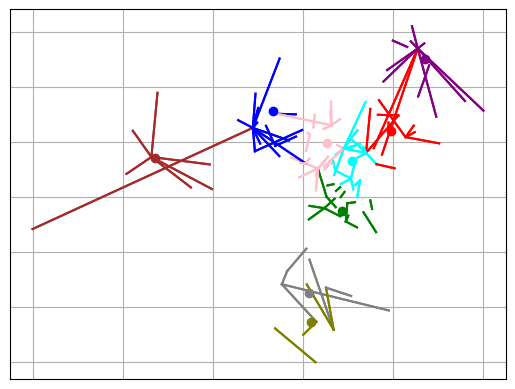

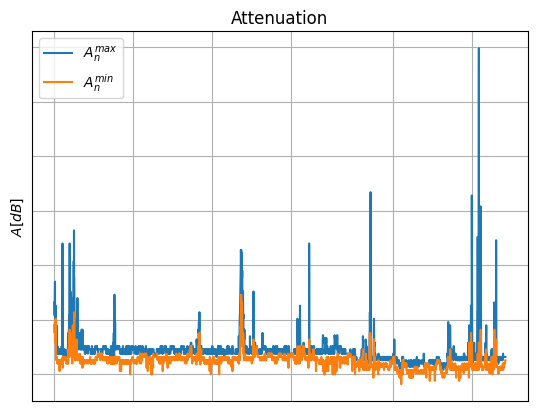

In [22]:
link_set, ps,_ = pnc.datasets.load_open_mrg(time_slice=time_slice, change2min_max=True)
link_set.plot_links(scale=True, scale_factor=1,scale_y=1)
plt.grid()
plt.tick_params(left=False, right=False, labelleft=False, labelbottom=False, bottom=False)
plt.title("")
plt.show()

link_set.get_link(0).plot()
plt.tick_params(left=False, right=False, labelleft=False, labelbottom=False, bottom=False)
plt.show()



In [24]:
# @title Statistics Wet Dry Hyper-parameters

statistics_wet_dry_threshold = 0.1  # @param{"type": "number"}
statistics_window_size = 8  # @param{"type": "integer"}
swd = pnc.scm.wet_dry.statistics_wet_dry(statistics_wet_dry_threshold, statistics_window_size,
                                         is_min_max=True)  # init classification model
wd_classification, std_vector = swd(link_set.get_link(0).attenuation())  # run classification method
ref = link_set.get_link(0).gauge_ref[0].data_array

In [25]:
# Pick link 0
link = link_set.get_link(0)

# Run wet/dry classification on attenuation time series
wd_classification, std_vector = swd(link.attenuation())

# Extract gauge reference safely (gauge_ref is a LIST)
gauge_refs = link.gauge_ref
if gauge_refs is None or len(gauge_refs) == 0:
    raise RuntimeError("This link has no gauge_ref attached (gauge_ref list is empty).")

# Use the first gauge reference (common default)
ref = gauge_refs[0].data_array


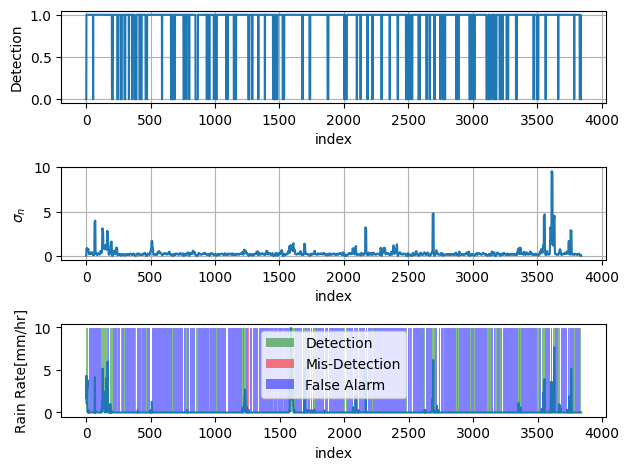

In [26]:
_, ax = plt.subplots(3, 1)
ax[0].plot(wd_classification.numpy()[0, :])
ax[0].set_xlabel('index')
ax[0].set_ylabel('Detection')
ax[0].grid()
ax[1].plot(std_vector.numpy()[0, :])
ax[1].set_xlabel('index')

ax[1].set_ylabel(r'$\sigma_n$')
ax[1].grid()
ax[2].plot(ref)
plot_wet_dry_detection_mark(ax[2], np.arange(len(ref)), wd_classification.numpy()[0, :-2], ref)
ax[2].legend()
ax[2].set_xlabel('index')
ax[2].set_ylabel(r'Rain Rate[mm/hr]')
plt.tight_layout()
plt.show()



In [27]:
# @title Rain Estimation Hyper-parameters
wa_factor = 1.6  # @param{"type": "number"}
r_min = 0.3  # @param{"type": "number"}
dynamic_baseline_window_size = 4  # @param{"type": "integer"}

In [28]:
tsc = pnc.scm.rain_estimation.two_step_constant_baseline(pnc.scm.power_law.PowerLawType.MAX, r_min,
                                                         statistics_window_size, statistics_wet_dry_threshold,
                                                         wa_factor=wa_factor)
os_baseline = pnc.scm.rain_estimation.one_step_dynamic_baseline(pnc.scm.power_law.PowerLawType.MAX, r_min,
                                                                dynamic_baseline_window_size, 1)

att = link_set.get_link(0).attenuation()
rain_ts, wd, ts_baseline_res = tsc(att,
                               link_set.get_link(0).meta_data)  # run constant baseline
rain_os, os_baseline_res = os_baseline(att,
                                   link_set.get_link(0).meta_data)

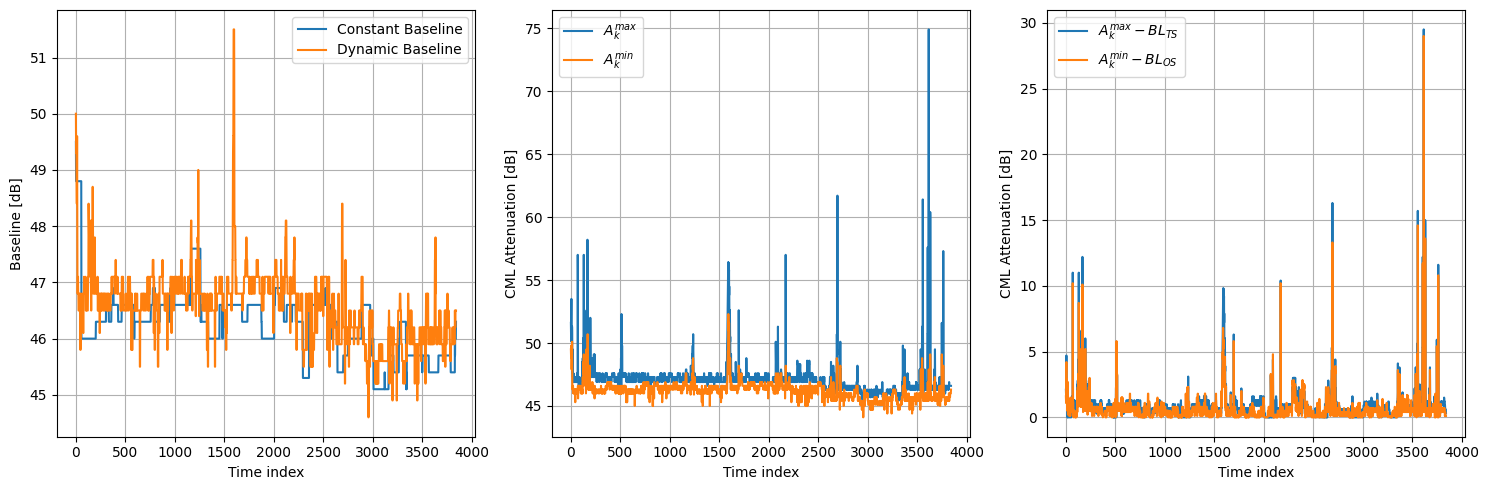

In [29]:
_, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].plot(ts_baseline_res.numpy().flatten(), label="Constant Baseline")
axs[0].plot(os_baseline_res.numpy().flatten(), label="Dynamic Baseline")
axs[0].set_xlabel("Time index")
axs[0].set_ylabel("Baseline [dB]")
axs[0].grid()
axs[0].legend()

axs[1].plot(att[0,:,0].numpy().flatten(), label=r"$A_{k}^{max}$")
axs[1].plot(att[0,:,1].numpy().flatten(), label=r"$A_{k}^{min}$")
axs[1].set_xlabel("Time index")
axs[1].set_ylabel("CML Attenuation [dB]")
axs[1].grid()
axs[1].legend()

axs[2].plot(np.maximum(att[0,:,0].numpy().flatten()-ts_baseline_res.numpy().flatten(),0), label=r"$A_{k}^{max}-BL_{TS}$")
axs[2].plot(np.maximum(att[0,:,0].numpy().flatten()-os_baseline_res.numpy().flatten(),0), label=r"$A_{k}^{min}-BL_{OS}$")
axs[2].set_xlabel("Time index")
axs[2].set_ylabel("CML Attenuation [dB]")
axs[2].grid()
axs[2].legend()

plt.tight_layout()
plt.show()

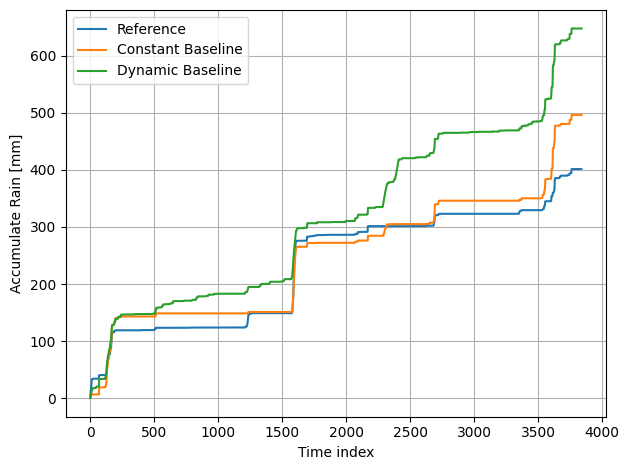

In [30]:
plt.plot(np.cumsum(ref), label="Reference")
plt.plot(np.cumsum(rain_ts), label="Constant Baseline")
plt.plot(np.cumsum(rain_os), label="Dynamic Baseline")
plt.xlabel("Time index")
plt.ylabel("Accumulate Rain [mm]")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

Lengths BEFORE alignment:
  rain_hat: 41888
  rain_ref: 41888
  rain_os : 3840

Lengths AFTER alignment:
  T: 3840

RMSE Results (Estimation, same-time):
  Two-Step RNN RMSE:     0.5446 mm
  Dynamic Baseline RMSE: 0.6506 mm


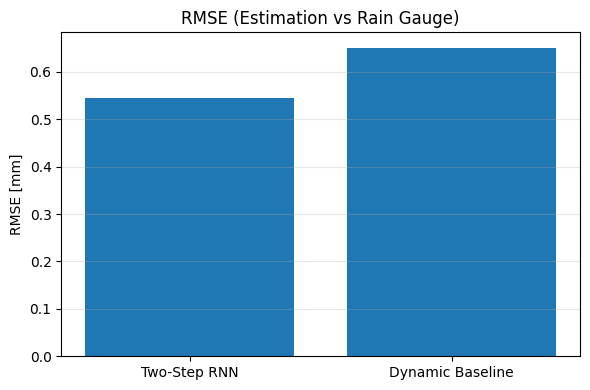

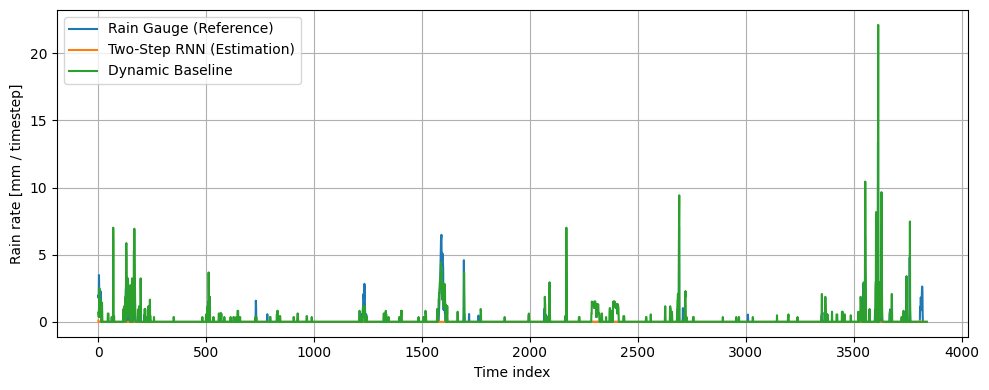

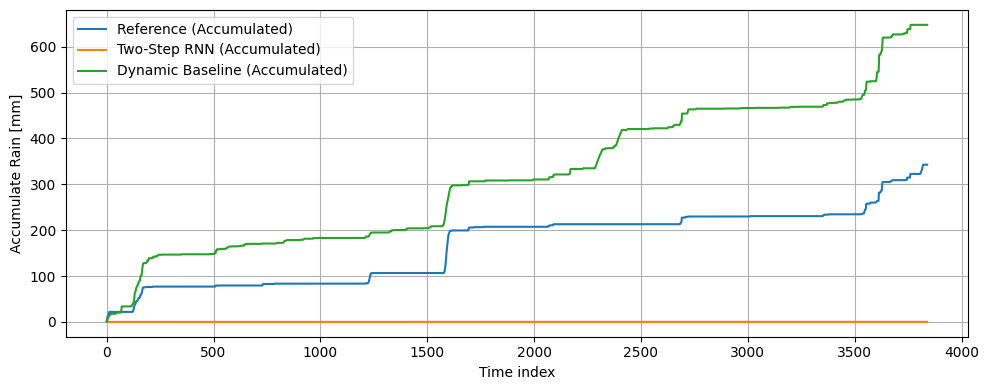

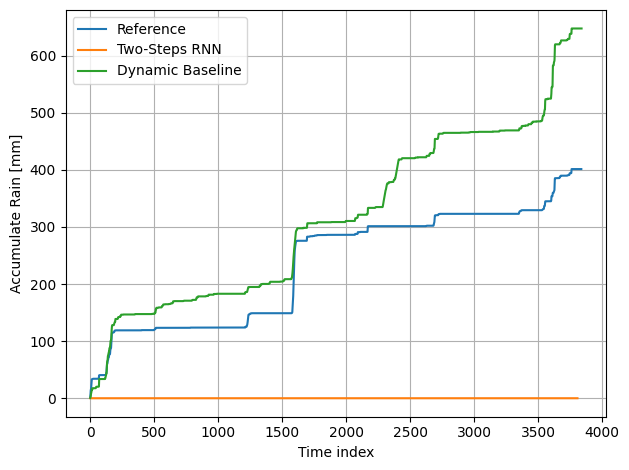

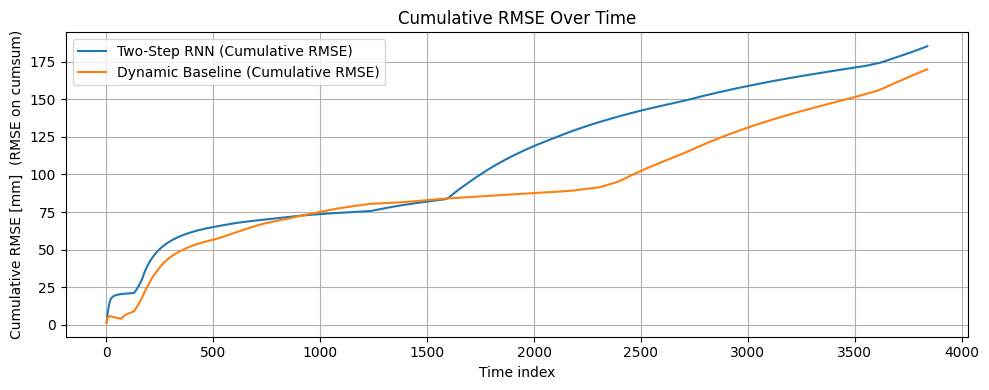

Final Cumulative RMSE (Two-Step RNN): 185.3348 mm
Final Cumulative RMSE (Baseline):     169.8455 mm


In [31]:

# =========================
# 1) Build 1D arrays (estimation, same-time alignment)
# =========================

# Two-Step RNN outputs and reference (from your lists)
rain_hat = np.concatenate(rain_hat_list, axis=1).reshape(-1)  # model estimation
rain_ref = np.concatenate(rain_ref_list, axis=1).reshape(-1)  # gauge reference aligned to estimation

# Dynamic baseline (make sure it's 1D)
rain_os_1d = np.asarray(rain_os).reshape(-1)

print("Lengths BEFORE alignment:")
print("  rain_hat:", len(rain_hat))
print("  rain_ref:", len(rain_ref))
print("  rain_os :", len(rain_os_1d))

# =========================
# 2) Align lengths (estimation: use SAME time index)
# =========================
T = min(len(rain_hat), len(rain_ref), len(rain_os_1d))

rain_hat = rain_hat[:T]
rain_ref = rain_ref[:T]
rain_os_1d = rain_os_1d[:T]

print("\nLengths AFTER alignment:")
print("  T:", T)

# =========================
# 3) RMSE function + compute RMSEs
# =========================
def rmse(pred, ref):
    pred = np.asarray(pred).reshape(-1)
    ref  = np.asarray(ref).reshape(-1)
    return np.sqrt(np.mean((pred - ref) ** 2))

# Optional: clip negative estimates (common in rain estimation)
rain_hat_clipped = np.maximum(rain_hat, 0)

rmse_rnn = rmse(rain_hat_clipped, rain_ref)
rmse_baseline = rmse(rain_os_1d, rain_ref)

print("\nRMSE Results (Estimation, same-time):")
print(f"  Two-Step RNN RMSE:     {rmse_rnn:.4f} mm")
print(f"  Dynamic Baseline RMSE: {rmse_baseline:.4f} mm")

# =========================
# 4) Plot RMSE bar chart
# =========================
methods = ["Two-Step RNN", "Dynamic Baseline"]
rmse_values = [rmse_rnn, rmse_baseline]

plt.figure(figsize=(6, 4))
plt.bar(methods, rmse_values)
plt.ylabel("RMSE [mm]")
plt.title("RMSE (Estimation vs Rain Gauge)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# =========================
# 5) (Optional) Plot raw signals (rain rate)
# =========================
plt.figure(figsize=(10, 4))
plt.plot(rain_ref, label="Rain Gauge (Reference)")
plt.plot(rain_hat_clipped, label="Two-Step RNN (Estimation)")
plt.plot(rain_os_1d, label="Dynamic Baseline")
plt.xlabel("Time index")
plt.ylabel("Rain rate [mm / timestep]")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 6) Plot accumulated rain )
# =========================
plt.figure(figsize=(10, 4))
plt.plot(np.cumsum(rain_ref), label="Reference (Accumulated)")
plt.plot(np.cumsum(rain_hat_clipped), label="Two-Step RNN (Accumulated)")
plt.plot(np.cumsum(rain_os_1d), label="Dynamic Baseline (Accumulated)")
plt.xlabel("Time index")
plt.ylabel("Accumulate Rain [mm]")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

#original code
plt.plot(np.cumsum(ref), label="Reference")

rain_hat_array = np.concatenate(rain_hat_list, axis=1)
rain_ref_array = np.concatenate(rain_ref_list, axis=1)

plt.plot(
    np.cumsum(np.maximum(rain_hat_array[0, :], 0)),
    label="Two-Steps RNN"
)

plt.plot(np.cumsum(rain_os), label="Dynamic Baseline")

plt.xlabel("Time index")
plt.ylabel("Accumulate Rain [mm]")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 7) Plot cumulative RMSE over time (RMSE on accumulated rain)
# =========================

cum_ref = np.cumsum(rain_ref)
cum_rnn = np.cumsum(rain_hat_clipped)
cum_base = np.cumsum(rain_os_1d)

# cumulative RMSE curve: RMSE from start up to time t
# start from 1 to avoid empty slice; you can start from 10 to reduce initial noise
start_t = 1

cum_rmse_rnn = np.array([
    np.sqrt(np.mean((cum_rnn[:t] - cum_ref[:t])**2))
    for t in range(start_t, T + 1)
])

cum_rmse_base = np.array([
    np.sqrt(np.mean((cum_base[:t] - cum_ref[:t])**2))
    for t in range(start_t, T + 1)
])

x = np.arange(start_t, T + 1)

plt.figure(figsize=(10, 4))
plt.plot(x, cum_rmse_rnn, label="Two-Step RNN (Cumulative RMSE)")
plt.plot(x, cum_rmse_base, label="Dynamic Baseline (Cumulative RMSE)")
plt.xlabel("Time index")
plt.ylabel("Cumulative RMSE [mm]  (RMSE on cumsum)")
plt.title("Cumulative RMSE Over Time")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

# Optional: print final cumulative-RMSE value (at end of series)
print(f"Final Cumulative RMSE (Two-Step RNN): {cum_rmse_rnn[-1]:.4f} mm")
print(f"Final Cumulative RMSE (Baseline):     {cum_rmse_base[-1]:.4f} mm")



len(ref_full)     = 958
len(ref_from_list)= 9280
diff (full - list)= -8322


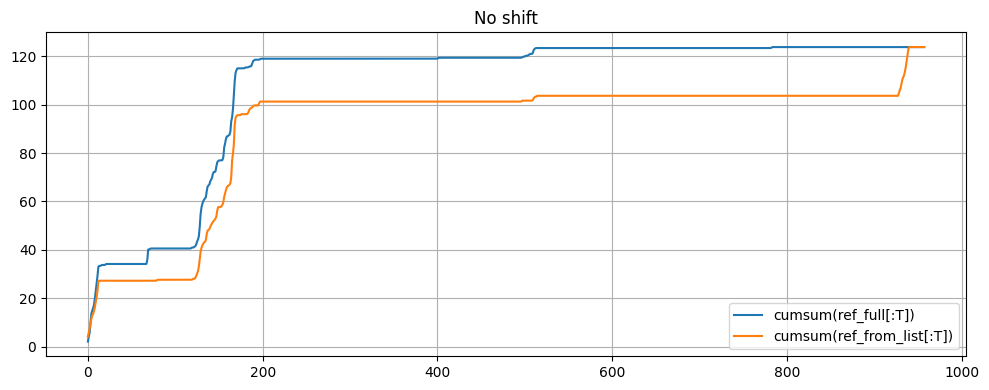

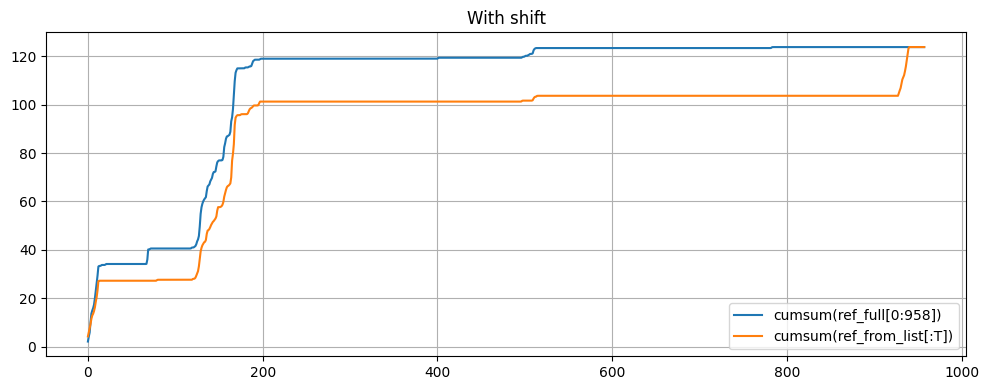

In [30]:
import numpy as np
import matplotlib.pyplot as plt

ref_full = np.asarray(ref).reshape(-1)  # ה-REF ה"אמיתי" שלך
ref_from_list = np.concatenate(rain_ref_list, axis=1).reshape(-1)  # REF מהחלונות

print("len(ref_full)     =", len(ref_full))
print("len(ref_from_list)=", len(ref_from_list))
print("diff (full - list)=", len(ref_full) - len(ref_from_list))

# נשווה אותם על אותו אורך, אבל נבדוק גם הסטה קדמית
T = min(len(ref_full), len(ref_from_list))

# 1) בלי הסטה: חיתוך רגיל מההתחלה
a = ref_full[:T]
b = ref_from_list[:T]

# 2) עם הסטה קדימה: אם ref_full ארוך יותר, ננסה להתחיל ממנו אחרי ה-diff
shift = max(len(ref_full) - len(ref_from_list), 0)
a_shifted = ref_full[shift:shift+T]

plt.figure(figsize=(10,4))
plt.plot(np.cumsum(a), label="cumsum(ref_full[:T])")
plt.plot(np.cumsum(b), label="cumsum(ref_from_list[:T])")
plt.title("No shift")
plt.grid(); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(10,4))
plt.plot(np.cumsum(a_shifted), label=f"cumsum(ref_full[{shift}:{shift+T}])")
plt.plot(np.cumsum(b), label="cumsum(ref_from_list[:T])")
plt.title("With shift")
plt.grid(); plt.legend(); plt.tight_layout(); plt.show()


In [29]:
imc = pnc.mcm.InferMultipleCMLs(os_baseline)
res = imc(link_set)
# @title IDW Hyper-parameters
region_of_interest = 3  # @param{"type": "integer"}
idw = pnc.mcm.generate_link_set_idw(link_set, roi=region_of_interest)
rain_map = idw(res).numpy()
# @title GMZ Hyper-parameters
point_per_link = 2  # @param{"type": "integer"}
gmz = pnc.mcm.generate_link_set_gmz(link_set, roi=region_of_interest, point_per_link=point_per_link)
rain_map_gmz, losses = gmz(res)
rain_map_gmz = rain_map_gmz.numpy()
print(type(res))
print(res)
# ואם יש שדות:
print(dir(res))


<class 'torch.Tensor'>
tensor([[0.6889, 0.5563, 0.3611,  ..., 0.0000, 0.0000, 0.0000],
        [0.8050, 1.0189, 0.8050,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [2.3513, 2.3513, 0.7367,  ..., 0.0000, 0.0000, 0.0000],
        [2.0821, 1.3519, 0.6461,  ..., 0.0000, 0.0000, 0.0000],
        [1.4325, 0.6891, 0.0000,  ..., 0.0000, 0.0000, 0.0000]])
['H', 'T', '__abs__', '__add__', '__and__', '__annotations__', '__array__', '__array_priority__', '__array_wrap__', '__bool__', '__class__', '__complex__', '__contains__', '__deepcopy__', '__delattr__', '__delitem__', '__dict__', '__dir__', '__div__', '__dlpack__', '__dlpack_device__', '__doc__', '__eq__', '__float__', '__floordiv__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__iadd__', '__iand__', '__idiv__', '__ifloordiv__', '__ilshift__', '__imod__', '__imul__', '__index__', '__init__', '__init_subclass__', '__int_

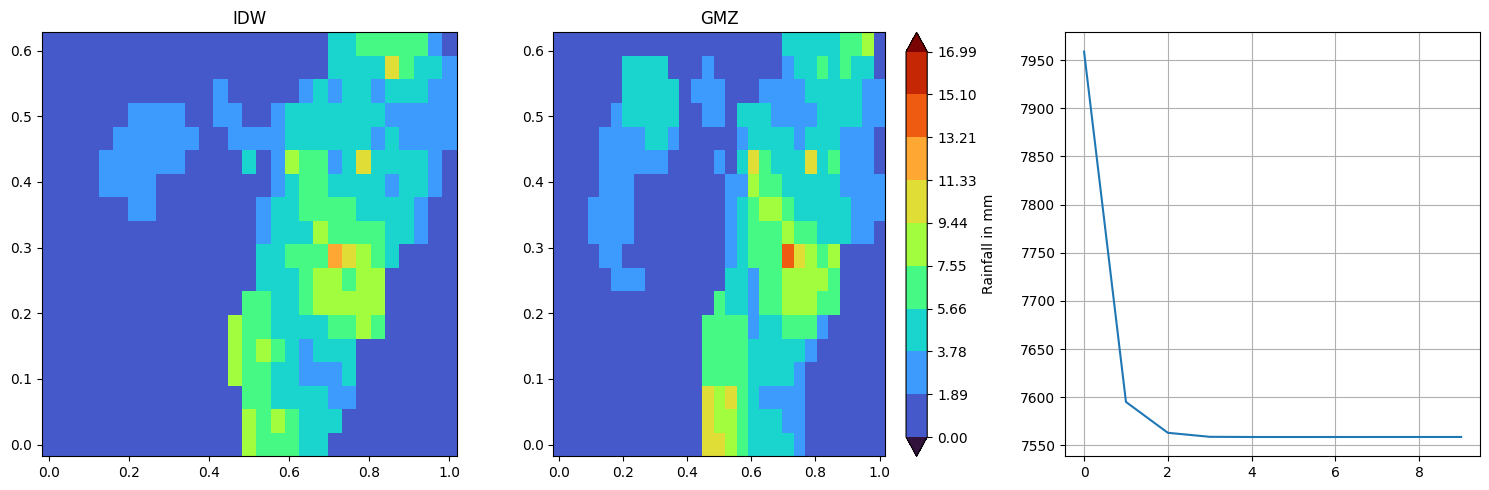

In [31]:
index = np.argmax(np.std(rain_map, axis=(1, 2)))

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
peak_rain = np.max([np.max(rain_map), np.max(rain_map_gmz)])
bounds = np.arange(0, peak_rain, peak_rain / 10)
# bounds[0] = 1

norm = mpl.colors.BoundaryNorm(boundaries=bounds, ncolors=256, extend='both')

pc_zero = ax[0].pcolormesh(
    idw.x_grid_vector,
    idw.y_grid_vector,
    rain_map[index, :, :].T,
    shading='nearest',
    cmap='turbo',
    norm=norm,
)
ax[0].set_title('IDW')
pc_one = ax[1].pcolormesh(
    idw.x_grid_vector,
    idw.y_grid_vector,
    rain_map_gmz[index, :, :].T,
    shading='nearest',
    cmap='turbo',
    norm=norm,
)
ax[1].set_title('GMZ')

ax[2].plot(losses[:, index])
ax[2].grid()
fig.colorbar(pc_one, label='Rainfall in mm')
plt.tight_layout()
plt.show()